In [12]:
# Import libraries used in this notebook
import os
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

In [32]:
# Write function to load PRTSZ transmission percent from file name
def load_prtsz_transmission(prtsz_file):
    """ Import PRTSZ data from CSV, use date and time
    columns to create Pandas datetime Index, and define
    Xarray Dataset object containing total volume
    concentration time series.
    Author: Kylene Cooley, 19 Apr 2024
    Inputs:
    -------
    prtsz_file, str of file name in local PRTSZ along shelf CTD 
        survey data directory
    Returns:
    --------
    vol_con, Data Array of total volume concentration from PRTSZ
        dataset with 1 dim = "time"
    """
    # Define path to locally saved PRTSZ data from CN site
    prtsz_path = os.path.join(os.path.expanduser(
    "~/Documents/Pioneer 20/pioneer-20_data/LISST_on_rosette/"),
    prtsz_file)
    # Import csv file using pandas and define variables
    prtsz_data = pd.read_csv(prtsz_path, header=None)
    transmission = prtsz_data[59]
    depth = prtsz_data[40]
    year = prtsz_data[42]
    month = prtsz_data[43]
    day = prtsz_data[44]
    hour = prtsz_data[45]
    minute = prtsz_data[46]
    second = prtsz_data[47]
    # Convert time parameter series to datetime vector
    dt_df = pd.DataFrame({"year": year, "month": month,
                        "day": day, "hour": hour,
                        "minute": minute, "second": second})
    prtsz_dt = pd.to_datetime(dt_df,
                            yearfirst=True, utc=True)
    # Create data array of total volume concentration with series
    prtsz_transmission = xr.Dataset(data_vars=dict(transmission=(["time"], transmission),
                                    depth=(["time"], depth)),
                            coords={"time": prtsz_dt}
                            )
    return prtsz_transmission

In [ ]:
# Load CTD cast #003 from AR82-B
prtsz_file = "AR82b_CAST003/ar82b_cast003_1071418_rs.csv"
prtsz_transmission = load_prtsz_transmission(prtsz_file)
prtsz_transmission

<xarray.Dataset>
Dimensions:       (time: 807)
Coordinates:
  * time          (time) datetime64[ns] 2024-04-16T14:18:22 ... 2024-04-16T14...
Data variables:
    transmission  (time) float64 0.94 0.941 0.932 0.939 ... 0.771 0.77 0.769
    depth         (time) float64 -1.09 -1.13 -1.13 -1.13 ... -0.87 -0.89 -0.88

## Evaluate Statistics on LISST Data

In [ ]:
# Filter the full data set for depths where the PRTSZ
# was submerged below the sea surface according to depth
prtsz_water = prtsz_transmission.where(
    prtsz_transmission.depth>0, drop=True)
prtsz_water

In [ ]:
# Evaluate mean percent transmission for data recorded below
# the sea surface as recorded by the PRTSZ 
prtsz_water.transmission.mean()

In [ ]:
# Evaluate mean percent transmission for all data recorded
prtsz_transmission.transmission.mean()

In [ ]:
# Check average percent transmission when PRTSZ is above the surface.
# The times with percent transmission less than 30% were recorded 
# after the CTD rosette came out of the water.
prtsz_transmission.transmission.where(prtsz_transmission.depth<=0, drop=True).mean()

## Plot Pioneer 20 LISST Optical Transmissioin on CTD Rosette

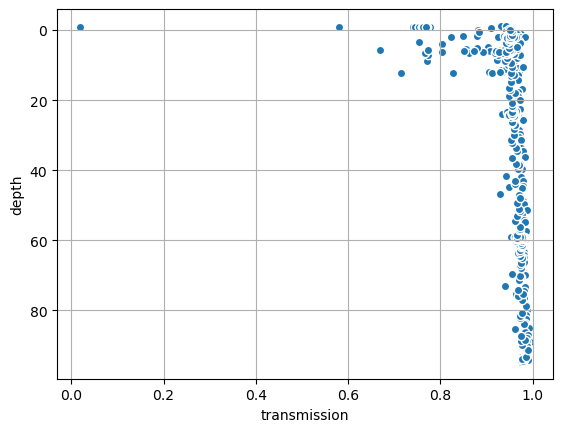

In [22]:
# Create scatter plot of optical transmission
fig1, ax1 = plt.subplots()
prtsz_transmission.plot.scatter(x="transmission", y="depth", ax=ax1)
ax1.invert_yaxis()
ax1.grid()
# fig1.show

In [14]:
# Filter the full data set for depths where the PRTSZ
# was submerged below the sea surface according to depth
prtsz_water = prtsz_transmission.where(
    prtsz_transmission.depth>0, drop=True)
prtsz_water

<xarray.Dataset>
Dimensions:       (time: 616)
Coordinates:
  * time          (time) datetime64[ns] 2024-04-16T14:22:10 ... 2024-04-16T14...
Data variables:
    transmission  (time) float64 0.942 0.954 0.951 0.924 ... 0.951 0.956 0.954
    depth         (time) float64 0.36 1.63 1.73 1.86 ... 1.26 1.67 1.55 0.39

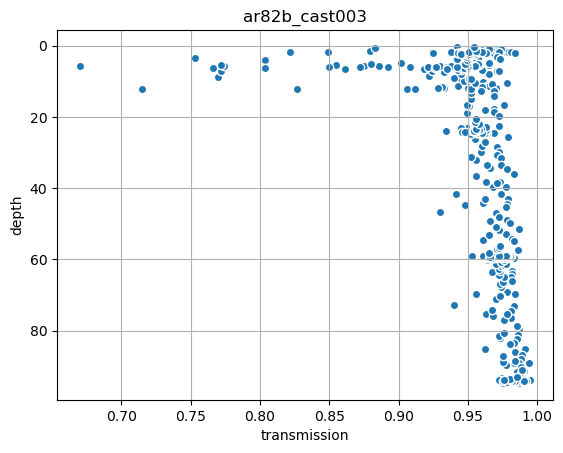

In [36]:
# Plot transmission when the instrument is in the water 
fig2, ax2 = plt.subplots()
prtsz_water.plot.scatter(x="transmission", y="depth", ax=ax2)
ax2.invert_yaxis()
plt.title(re.findall("[a-zA-Z]{2}.*cast[0-9]{3}", prtsz_file)[-1])
ax2.grid()

In [ ]:
# Define plotting function
def lisst_cast_scatter(data_water, file):
    fig0, ax0 = plt.subplots()
    data_water.plot.scatter(marker="*", x="transmission", y="depth", ax=ax0, edgecolors="none")
    ax0.invert_yaxis()
    plt.title(re.findall("[a-zA-Z]{2}.*cast[0-9]{3}", file)[0])
    ax0.grid()
    ax0.axvline(0.995, linestyle="r--")
    return fig0, ax0

## Use functions to plot all AR82 data saved locally

ValueError: ymin must be a single scalar value, but got r--

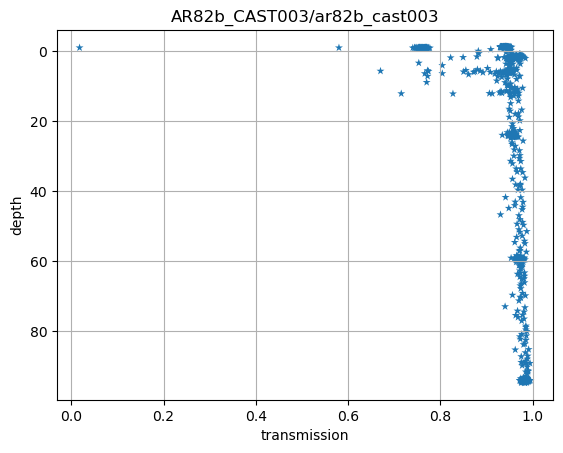

In [96]:
# LISST data from AR82b cast 003
ar82b3_file = "AR82b_CAST003/ar82b_cast003_1071418_rs.csv"
ar82b3_transmission = load_prtsz_transmission(ar82b3_file)
fig_ar82b3, ax_ar82b3 = lisst_cast_scatter(ar82b3_transmission, ar82b3_file)

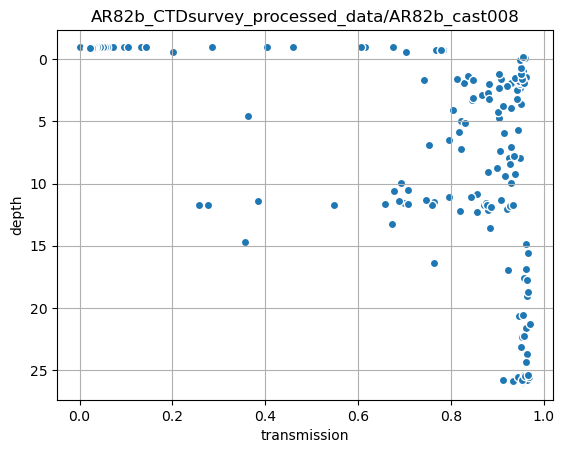

In [35]:
# LISST data from AR82b cast 008
ar82b8_file = "AR82b_CTDsurvey_processed_data/AR82b_cast008_CS1_rs.csv"
ar82b8_transmission = load_prtsz_transmission(ar82b8_file)
fig_ar82b8, ax_ar82b8 = lisst_cast_scatter(ar82b8_transmission, ar82b8_file)

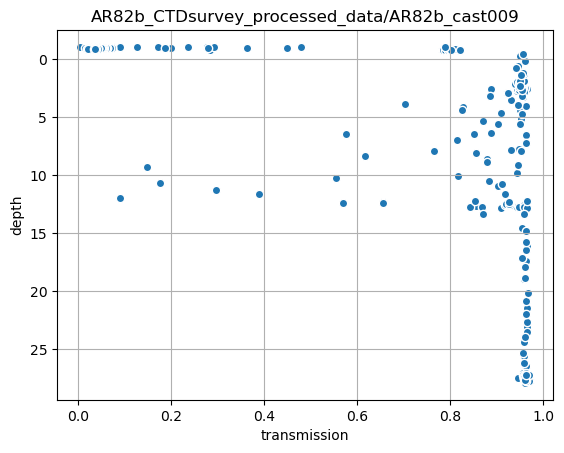

In [37]:
# LISST data from AR82b cast 009
ar82b9_file = "AR82b_CTDsurvey_processed_data/AR82b_cast009_CN_rs.csv"
ar82b9_transmission = load_prtsz_transmission(ar82b9_file)
fig_ar82b9, ax_ar82b9 = lisst_cast_scatter(ar82b9_transmission, ar82b9_file)

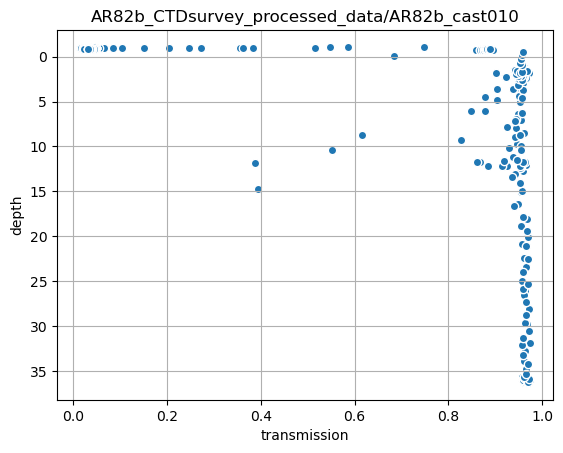

In [ ]:
# LISST data from AR82b cast 010
ar82b10_file = "AR82b_CTDsurvey_processed_data/AR82b_cast010_CS2_rs.csv"
ar82b10_transmission = load_prtsz_transmission(ar82b10_file)
fig_ar82b10, ax_ar82b10 = lisst_cast_scatter(ar82b10_transmission, ar82b10_file)

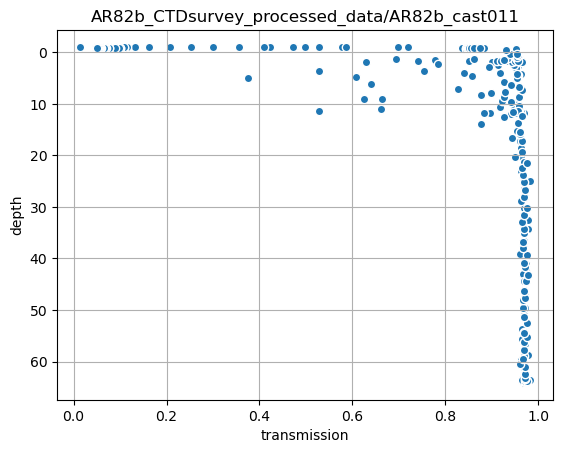

In [39]:
# LISST data from AR82b cast 011
ar82b11_file = "AR82b_CTDsurvey_processed_data/AR82b_cast011_CS3_rs.csv"
ar82b11_transmission = load_prtsz_transmission(ar82b11_file)
fig_ar82b11, ax_ar82b11 = lisst_cast_scatter(ar82b11_transmission, ar82b11_file)

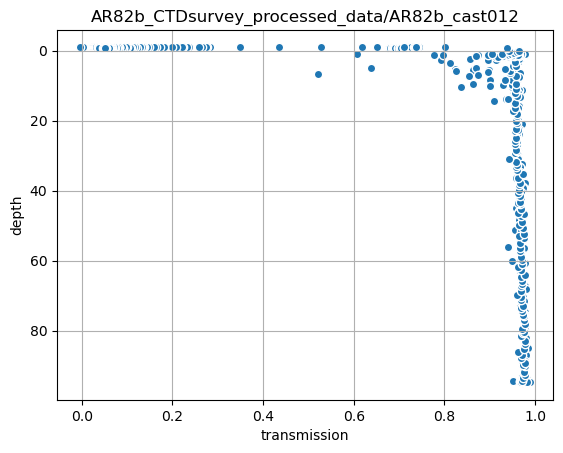

In [40]:
# LISST data from AR82b cast 012
ar82b12_file = "AR82b_CTDsurvey_processed_data/AR82b_cast012_EA_rs.csv"
ar82b12_transmission = load_prtsz_transmission(ar82b12_file)
fig_ar82b12, ax_ar82b12 = lisst_cast_scatter(ar82b12_transmission, ar82b12_file)

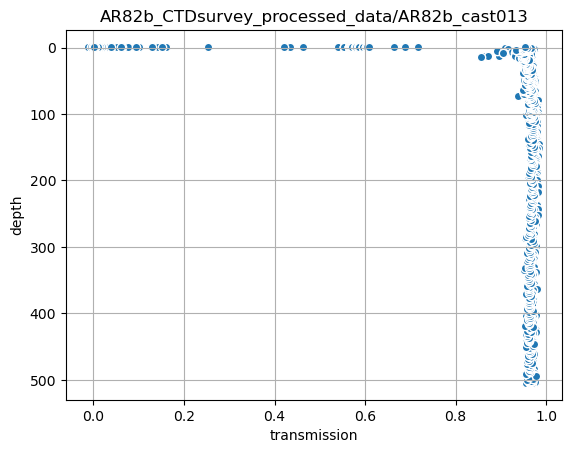

In [42]:
# LISST data from AR82b cast 013
ar82b13_file = "AR82b_CTDsurvey_processed_data/AR82b_cast013_CS4_rs.csv"
ar82b13_transmission = load_prtsz_transmission(ar82b13_file)
fig_ar82b13, ax_ar82b13 = lisst_cast_scatter(ar82b13_transmission, ar82b13_file)

## Create pcolor plot for AR82b cross-shelf survey

In [56]:
# Make list object of datasets for cross-shelf survey
crossshelf = [ar82b8_transmission, ar82b9_transmission,
              ar82b10_transmission, ar82b11_transmission,
              ar82b12_transmission]

In [82]:
for waypt, cast_data in enumerate(crossshelf):
    cast_water = cast_data.where(cast_data.depth>0, drop=True)
    cast_water = cast_water.assign(station=waypt*np.ones_like(cast_water.depth))
    crossshelf[waypt] = cast_water


In [83]:
crossshelf[0]

<xarray.Dataset>
Dimensions:       (time: 149, station: 149)
Coordinates:
  * time          (time) datetime64[ns] 2024-04-18T12:54:45 ... 2024-04-18T12...
  * station       (station) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    transmission  (time) float64 0.954 0.952 0.947 0.939 ... 0.95 0.951 0.948
    depth         (time) float64 0.96 1.76 1.68 1.88 ... 1.58 1.19 0.67 0.08

In [ ]:
cross_ds = xr.combine_by_coords(crossshelf)

In [62]:
cross_ds

<xarray.Dataset>
Dimensions:       (time: 2258, station: 2258)
Coordinates:
  * time          (time) datetime64[ns] 2024-04-18T12:52:39 ... 2024-04-18T16...
  * station       (station) float64 0.0 0.0 0.0 0.0 0.0 ... 4.0 4.0 4.0 4.0 4.0
Data variables:
    transmission  (station, time) float64 0.775 0.78 0.776 ... 0.052 0.048 0.052
    depth         (station, time) float64 -0.71 -0.76 -0.78 ... -0.84 -0.84

In [ ]:
crossshelf

'transmission'

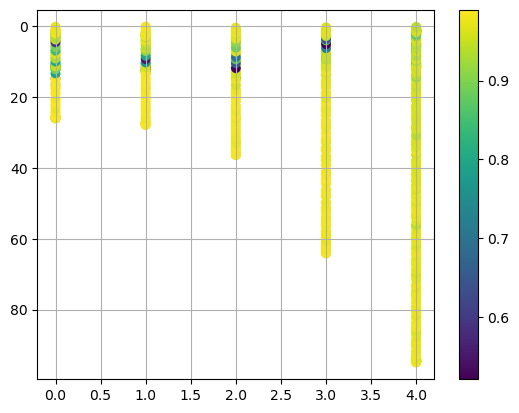

In [86]:
# Plot cross shelf data with pcolormesh
fig3, ax3 = plt.subplots()
for cast_data in crossshelf:
    plt.scatter(cast_data["station"].astype(int), cast_data["depth"],
                   c=cast_data["transmission"])
ax3.invert_yaxis()
ax3.grid()
plt.colorbar()